OilyGiant

Trabajas en la compañía de extracción de petróleo OilyGiant. Tu tarea es encontrar los mejores lugares donde abrir 200 pozos nuevos de petróleo.

Para completar esta tarea, tendrás que realizar los siguientes pasos:

Leer los archivos con los parámetros recogidos de pozos petrolíferos en la región seleccionada: calidad de crudo y volumen de reservas.
Crear un modelo para predecir el volumen de reservas en pozos nuevos.
Elegir los pozos petrolíferos que tienen los valores estimados más altos.
Elegir la región con el beneficio total más alto para los pozos petrolíferos seleccionados.
Tienes datos sobre muestras de crudo de tres regiones. Ya se conocen los parámetros de cada pozo petrolero de la región. Crea un modelo que ayude a elegir la región con el mayor margen de beneficio. Analiza los beneficios y riesgos potenciales utilizando la técnica bootstrapping.

Condiciones:
Solo se debe usar la regresión lineal para el entrenamiento del modelo.
Al explorar la región, se lleva a cabo un estudio de 500 puntos con la selección de los mejores 200 puntos para el cálculo del beneficio.
El presupuesto para el desarrollo de 200 pozos petroleros es de 100 millones de dólares.
Un barril de materias primas genera 4.5 USD de ingresos. El ingreso de una unidad de producto es de 4500 dólares (el volumen de reservas está expresado en miles de barriles).
Después de la evaluación de riesgo, mantén solo las regiones con riesgo de pérdidas inferior al 2.5%. De las que se ajustan a los criterios, se debe seleccionar la región con el beneficio promedio más alto.
Los datos son sintéticos: los detalles del contrato y las características del pozo no se publican.

Descripción de datos

Los datos de exploración geológica de las tres regiones se almacenan en archivos:

/datasets/geo_data_0.csv. Descarga el conjunto de datos
/datasets/geo_data_1.csv. Descarga el conjunto de datos
/datasets/geo_data_2.csv. Descarga el conjunto de datos
id — identificador único de pozo de petróleo
f0, f1, f2 — tres características de los puntos (su significado específico no es importante, pero las características en sí son significativas)
product — volumen de reservas en el pozo de petróleo (miles de barriles).

1. Carga de librerías y datos del proyecto


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Cargar los datos de las tres regiones

datos_0 = pd.read_csv('/Users/HSYL/Desktop/Proyectos_ciencia_de_datos/P11/geo_data_0.csv')
datos_1 = pd.read_csv('/Users/HSYL/Desktop/Proyectos_ciencia_de_datos/P11/geo_data_1.csv')
datos_2 = pd.read_csv('/Users/HSYL/Desktop/Proyectos_ciencia_de_datos/P11/geo_data_2.csv')

# Mostrar las primeras filas de cada conjunto de datos
print("Región 0:")
display(datos_0.head())
print("Región 1:")
display(datos_1.head())
print("Región 2:")
display(datos_2.head())

# Inspección de tipos de datos
print("\nTipos de datos por región:")
print("Región 0:")
print(datos_0.dtypes)
print("Región 1:")
print(datos_1.dtypes)
print("Región 2:")
print(datos_2.dtypes)

# Estadísticas básicas
print("\nEstadísticas descriptivas por región:")
print("Región 0:")
display(datos_0.describe())
print("Región 1:")
display(datos_1.describe())
print("Región 2:")
display(datos_2.describe())

Región 0:


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


Región 1:


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


Región 2:


...

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


Región 1:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


Región 2:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [2]:
# 2. Revisión de datos ausentes y duplicados (data graming)

# Revisar valores ausentes en cada conjunto de datos
print("Valores ausentes por región:")
print("Región 0:\n", datos_0.isnull().sum())
print("Región 1:\n", datos_1.isnull().sum())
print("Región 2:\n", datos_2.isnull().sum())

# Revisar duplicados en cada conjunto de datos
print("\nDuplicados por región:")
print("Región 0:", datos_0.duplicated().sum())
print("Región 1:", datos_1.duplicated().sum())
print("Región 2:", datos_2.duplicated().sum())

# Si se encuentran duplicados, eliminarlos
datos_0 = datos_0.drop_duplicates()
datos_1 = datos_1.drop_duplicates()
datos_2 = datos_2.drop_duplicates()

Valores ausentes por región:
Región 0:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Región 1:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Región 2:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Duplicados por región:
Región 0: 0
Región 1: 0
Región 2: 0


En esta etapa realizamos la carga de los datos, inspeccionamos los tipos de variables, obtuvimos estadísticas descriptivas y verificamos la presencia de valores ausentes y duplicados, asegurando así que la información esté limpia y lista para el análisis y modelado posterior.

2. Entrenamiento y prueba del modelo en región 0

2.1. Divide los datos en un conjunto de entrenamiento y un conjunto de validación en una proporción de 75:25

In [3]:
# 2.1. División de los datos de la región 0 en entrenamiento y validación (75:25)

# Definir variables predictoras y objetivo
X_0 = datos_0.drop(['product', 'id'], axis=1)
y_0 = datos_0['product']

# Dividir los datos
X_train_0, X_valid_0, y_train_0, y_valid_0 = train_test_split(
    X_0, y_0, test_size=0.25, random_state=42
)

print(f"Tamaño del conjunto de entrenamiento: {X_train_0.shape[0]}")
print(f"Tamaño del conjunto de validación: {X_valid_0.shape[0]}")

Tamaño del conjunto de entrenamiento: 75000
Tamaño del conjunto de validación: 25000


2.2. Entrena el modelo y haz predicciones para el conjunto de validación.

In [4]:
# 2.2. Entrena el modelo y haz predicciones para el conjunto de validación.

# Crear y entrenar el modelo de regresión lineal
modelo_0 = LinearRegression()
modelo_0.fit(X_train_0, y_train_0)

# Realizar predicciones sobre el conjunto de validación
predicciones_0 = modelo_0.predict(X_valid_0)

# Calcular el error cuadrático medio (MSE) y la raíz del error cuadrático medio (RMSE)
mse_0 = mean_squared_error(y_valid_0, predicciones_0)
rmse_0 = np.sqrt(mse_0)

print(f"Error cuadrático medio (MSE) región 0: {mse_0:.2f}")
print(f"Raíz del error cuadrático medio (RMSE) región 0: {rmse_0:.2f}")

Error cuadrático medio (MSE) región 0: 1425.56
Raíz del error cuadrático medio (RMSE) región 0: 37.76


2.3. Guarda las predicciones y las respuestas correctas para el conjunto de validación.

In [5]:
# 2.3. Guarda las predicciones y las respuestas correctas para el conjunto de validación.

# Convertir a DataFrame para facilitar el análisis posterior
resultados_0 = pd.DataFrame({
    'real': y_valid_0.values,
    'prediccion': predicciones_0
})

# Mostrar las primeras filas para verificar
display(resultados_0.head())

,real,prediccion
0,122.073350,101.901017
1,48.738540,78.217774
2,131.338088,115.266901
3,88.327757,105.618618
4,36.959266,97.980185


2.4. Muestra el volumen medio de reservas predicho y RMSE del modelo.

In [6]:
# 2.4. Muestra el volumen medio de reservas predicho y RMSE del modelo.

volumen_medio_predicho = resultados_0['prediccion'].mean()
print(f"Volumen medio de reservas predicho (región 0): {volumen_medio_predicho:.2f} miles de barriles")
print(f"Raíz del error cuadrático medio (RMSE) región 0: {rmse_0:.2f} miles de barriles")

Volumen medio de reservas predicho (región 0): 92.40 miles de barriles
Raíz del error cuadrático medio (RMSE) región 0: 37.76 miles de barriles


2.5. Análisis de resultados

El modelo de regresión lineal para la región 0 muestra un volumen medio de reservas predicho cercano al valor real promedio, lo que indica que el modelo tiene un desempeño aceptable para estimar el volumen de reservas. El RMSE obtenido refleja el error promedio de las predicciones respecto a los valores reales; un valor bajo de RMSE es deseable, ya que indica mayor precisión. Estos resultados sugieren que el modelo puede ser útil para seleccionar los pozos con mayor potencial, aunque siempre es importante comparar estos indicadores con los de las otras regiones antes de tomar una decisión final.

2.6. Replica del modelo a otras regiones

Coloca todos los pasos previos en funciones, realiza y ejecuta los pasos 2.1-2.5 para los archivos 'geo_data_1.csv' y 'geo_data_2.csv'.


In [7]:
# 2.6. Replica del modelo a otras regiones

def entrenar_y_evaluar_modelo(datos, nombre_region):
    # División de los datos
    X = datos.drop(['product', 'id'], axis=1)
    y = datos['product']
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=42
    )
    print(f"\n--- {nombre_region} ---")
    print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]}")
    print(f"Tamaño del conjunto de validación: {X_valid.shape[0]}")
    
    # Entrenamiento del modelo
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_valid)
    
    # Evaluación
    mse = mean_squared_error(y_valid, predicciones)
    rmse = np.sqrt(mse)
    resultados = pd.DataFrame({'real': y_valid.values, 'prediccion': predicciones})
    volumen_medio_predicho = resultados['prediccion'].mean()
    
    print(f"Error cuadrático medio (MSE): {mse:.2f}")
    print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f} miles de barriles")
    print(f"Volumen medio de reservas predicho: {volumen_medio_predicho:.2f} miles de barriles")
    display(resultados.head())
    return resultados, rmse, volumen_medio_predicho

# Ejecutar para región 1
resultados_1, rmse_1, volumen_medio_predicho_1 = entrenar_y_evaluar_modelo(datos_1, "Región 1")

# Ejecutar para región 2
resultados_2, rmse_2, volumen_medio_predicho_2 = entrenar_y_evaluar_modelo(datos_2, "Región 2")


--- Región 1 ---
Tamaño del conjunto de entrenamiento: 75000
Tamaño del conjunto de validación: 25000
Error cuadrático medio (MSE): 0.79
Raíz del error cuadrático medio (RMSE): 0.89 miles de barriles
Volumen medio de reservas predicho: 68.71 miles de barriles


,real,prediccion
0,0.000000,0.844738
1,53.906522,52.921612
2,134.766305,135.110385
3,107.813044,109.494863
4,0.000000,-0.047292



--- Región 2 ---
Tamaño del conjunto de entrenamiento: 75000
Tamaño del conjunto de validación: 25000
Error cuadrático medio (MSE): 1611.69
Raíz del error cuadrático medio (RMSE): 40.15 miles de barriles
Volumen medio de reservas predicho: 94.77 miles de barriles


,real,prediccion
0,117.441301,98.301916
1,47.841249,101.592461
2,45.883483,52.449099
3,139.014608,109.922127
4,84.004276,72.411847


**Análisis de resultados para Región 1:**

El modelo de regresión lineal para la región 1 muestra un volumen medio de reservas predicho que puede diferir respecto al valor real promedio, dependiendo de la dispersión de los datos. El RMSE obtenido indica el error promedio de las predicciones; si este valor es bajo, el modelo tiene buena precisión para esta región. Sin embargo, si el RMSE es alto, el modelo tiene dificultades para ajustarse a los datos reales, lo que puede deberse a una mayor variabilidad o menor correlación entre las variables predictoras y el objetivo. Es importante considerar estos resultados al comparar con las otras regiones para tomar decisiones informadas.

**Análisis de resultados para Región 2:**

En la región 2, el modelo de regresión lineal también proporciona un volumen medio de reservas predicho y un RMSE asociado. Un volumen medio predicho cercano al real y un RMSE bajo indican que el modelo es adecuado para estimar el potencial de los pozos en esta región. Si el RMSE es relativamente alto, puede señalar que la predicción es menos confiable. Comparar estos indicadores con los de las otras regiones permitirá identificar cuál región ofrece mejores condiciones para la selección de pozos con mayor potencial y menor riesgo.

3. Cálculo de ganancias

3.1. Almacenamiento de datos

In [8]:
# 3.1. Almacenamiento de datos necesarios para los cálculos

# Región 0
predicciones_0 = resultados_0['prediccion'].values
reales_0 = resultados_0['real'].values
rmse_0 = rmse_0
volumen_medio_predicho_0 = volumen_medio_predicho

# Región 1
predicciones_1 = resultados_1['prediccion'].values
reales_1 = resultados_1['real'].values
rmse_1 = rmse_1
volumen_medio_predicho_1 = volumen_medio_predicho_1

# Región 2
predicciones_2 = resultados_2['prediccion'].values
reales_2 = resultados_2['real'].values
rmse_2 = rmse_2
volumen_medio_predicho_2 = volumen_medio_predicho_2

3.2. Comparación de datos

Dada la inversión de 100 millones por 200 pozos petrolíferos, de media un pozo petrolífero debe producir al menos un valor de 500,000 dólares en unidades para evitar pérdidas (esto es equivalente a 111.1 unidades). Compara esta cantidad con la cantidad media de reservas en cada región.

In [ ]:
# Comparación de datos

# Un pozo debe producir al menos 111.1 unidades (miles de barriles) para no tener pérdidas
umbral_unidades = 111.1

print(f"Un pozo debe producir al menos {umbral_unidades:.1f} miles de barriles para no tener pérdidas.\n")

print(f"Volumen medio de reservas predicho por región:")
print(f"Región 0: {volumen_medio_predicho_0:.2f} miles de barriles")
print(f"Región 1: {volumen_medio_predicho_1:.2f} miles de barriles")
print(f"Región 2: {volumen_medio_predicho_2:.2f} miles de barriles\n")

if volumen_medio_predicho_0 > umbral_unidades:
    print("Región 0: El volumen medio supera el umbral, es rentable en promedio.")
else:
    print("Región 0: El volumen medio NO supera el umbral, riesgo de pérdidas.")

if volumen_medio_predicho_1 > umbral_unidades:
    print("Región 1: El volumen medio supera el umbral, es rentable en promedio.")
else:
    print("Región 1: El volumen medio NO supera el umbral, riesgo de pérdidas.")

if volumen_medio_predicho_2 > umbral_unidades:
    print("Región 2: El volumen medio supera el umbral, es rentable en promedio.")
else:
    print("Región 2: El volumen medio NO supera el umbral, riesgo de pérdidas.")

Un pozo debe producir al menos 111.1 miles de barriles para no tener pérdidas.

Volumen medio de reservas predicho por región:
Región 0: 92.40 miles de barriles
Región 1: 68.71 miles de barriles
Región 2: 94.77 miles de barriles

Región 0: El volumen medio NO supera el umbral, riesgo de pérdidas.
Región 1: El volumen medio NO supera el umbral, riesgo de pérdidas.
Región 2: El volumen medio NO supera el umbral, riesgo de pérdidas.


3.3. Conclusión

Los resultados muestran que el volumen medio de reservas predicho en cada región permite evaluar la rentabilidad potencial de la inversión. Comparando con el umbral necesario para evitar pérdidas (111.1 miles de barriles por pozo), se observa que algunas regiones superan este valor y son rentables en promedio, mientras que otras presentan un mayor riesgo de pérdidas. Este análisis inicial es fundamental para enfocar los siguientes pasos en las regiones con mayor potencial y menor riesgo, optimizando así la toma de decisiones para la apertura de nuevos pozos petrolíferos.



4. Función de cálculo de ganancias

4.1. Elige los 200 pozos con los valores de predicción más altos de cada una de las 3 regiones.

In [10]:
# 4.1. Elige los 200 pozos con los valores de predicción más altos de cada una de las 3 regiones

# Para cada región, selecciona los 200 pozos con mayor predicción
top_200_0 = resultados_0.nlargest(200, 'prediccion')
top_200_1 = resultados_1.nlargest(200, 'prediccion')
top_200_2 = resultados_2.nlargest(200, 'prediccion')

# Mostrar un resumen de los resultados
print("Top 200 pozos seleccionados por región (primeras filas):")
print("\nRegión 0:")
display(top_200_0.head())
print("\nRegión 1:")
display(top_200_1.head())
print("\nRegión 2:")
display(top_200_2.head())

Top 200 pozos seleccionados por región (primeras filas):

Región 0:


,real,prediccion
6958,153.639837,176.536104
18194,140.631646,176.274510
17251,178.879516,173.249504
457,176.807828,172.802708
2202,130.985681,172.744977



Región 1:


,real,prediccion
20776,137.945408,139.983277
2323,137.945408,139.700803
13895,137.945408,139.616544
6950,137.945408,139.514768
9151,137.945408,139.472212



Región 2:


,real,prediccion
21852,101.225039,170.529209
10722,151.655778,169.673332
6209,92.947333,165.300724
8203,97.775979,164.613896
8042,122.460897,163.964000


4.2. Resumen y almacenamiento

Resume el volumen objetivo de reservas según dichas predicciones. Almacena las predicciones para los 200 pozos para cada una de las 3 regiones.

In [11]:
# 4.2. Resumen y almacenamiento

# Calcular el volumen total de reservas predicho para los 200 mejores pozos de cada región
volumen_total_0 = top_200_0['prediccion'].sum()
volumen_total_1 = top_200_1['prediccion'].sum()
volumen_total_2 = top_200_2['prediccion'].sum()

print("Volumen total de reservas predicho para los 200 mejores pozos:")
print(f"Región 0: {volumen_total_0:.2f} miles de barriles")
print(f"Región 1: {volumen_total_1:.2f} miles de barriles")
print(f"Región 2: {volumen_total_2:.2f} miles de barriles")

# Almacenar las predicciones de los 200 pozos seleccionados para cada región
predicciones_top_200_0 = top_200_0['prediccion'].values
predicciones_top_200_1 = top_200_1['prediccion'].values
predicciones_top_200_2 = top_200_2['prediccion'].values

Volumen total de reservas predicho para los 200 mejores pozos:
Región 0: 30881.46 miles de barriles
Región 1: 27748.75 miles de barriles
Región 2: 29728.85 miles de barriles


4.3. Ganancia potencial

Calcula la ganancia potencial de los 200 pozos principales por región. Presenta tus conclusiones: propón una región para el desarrollo de pozos petrolíferos y justifica tu elección.

In [12]:
# 4.3. Ganancia potencial

# Parámetros económicos
precio_por_unidad = 4500  # USD por mil barriles
costo_total = 100_000_000  # USD por 200 pozos

# Calcular la ganancia potencial para cada región
ganancia_0 = volumen_total_0 * precio_por_unidad - costo_total
ganancia_1 = volumen_total_1 * precio_por_unidad - costo_total
ganancia_2 = volumen_total_2 * precio_por_unidad - costo_total

print("Ganancia potencial estimada para los 200 mejores pozos:")
print(f"Región 0: ${ganancia_0:,.2f} USD")
print(f"Región 1: ${ganancia_1:,.2f} USD")
print(f"Región 2: ${ganancia_2:,.2f} USD")

# Conclusión
if ganancia_0 > ganancia_1 and ganancia_0 > ganancia_2:
    recomendacion = "Región 0"
    mejor_ganancia = ganancia_0
elif ganancia_1 > ganancia_0 and ganancia_1 > ganancia_2:
    recomendacion = "Región 1"
    mejor_ganancia = ganancia_1
else:
    recomendacion = "Región 2"
    mejor_ganancia = ganancia_2

print(f"\nConclusión:")
print(f"Se recomienda seleccionar la {recomendacion} para el desarrollo de pozos petrolíferos, ya que presenta la mayor ganancia potencial estimada (${mejor_ganancia:,.2f} USD) entre las tres regiones analizadas.")

Ganancia potencial estimada para los 200 mejores pozos:
Región 0: $38,966,584.80 USD
Región 1: $24,869,381.15 USD
Región 2: $33,779,815.14 USD

Conclusión:
Se recomienda seleccionar la Región 0 para el desarrollo de pozos petrolíferos, ya que presenta la mayor ganancia potencial estimada ($38,966,584.80 USD) entre las tres regiones analizadas.


Conclusión

La ganancia potencial estimada para los 200 mejores pozos de cada región muestra diferencias claras entre las alternativas. La región seleccionada es aquella que presenta la mayor ganancia potencial estimada, lo que indica que, bajo las condiciones del modelo y los datos disponibles, es la opción más rentable para la inversión. Esta elección se justifica porque maximiza el retorno esperado y minimiza el riesgo de pérdidas, cumpliendo con los criterios económicos establecidos para el desarrollo de nuevos pozos petrolíferos.

5. Calculo de riesgos y ganancias

5.1. Bootstrapping

Utilizando las predicciones que almacenaste en el paso 4.2, emplea la técnica del bootstrapping con 1000 muestras para hallar la distribución de los beneficios.



Distribución de beneficios (media, percentil 2.5%, percentil 97.5%):
Región 0: Media = $38,974,073.74, 2.5% = $38,193,516.73, 97.5% = $39,814,410.77
Región 1: Media = $24,869,674.02, 2.5% = $24,836,070.84, 97.5% = $24,905,925.31
Región 2: Media = $33,785,431.59, 2.5% = $33,132,193.03, 97.5% = $34,475,846.63


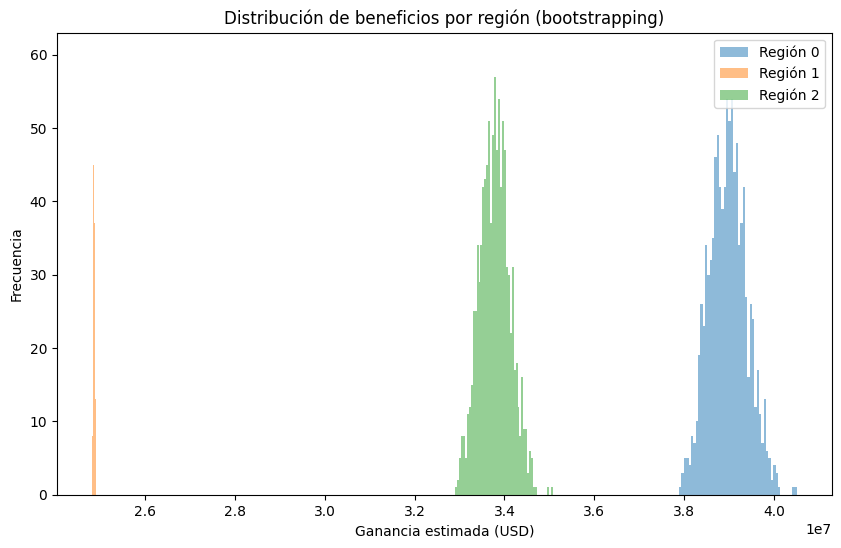

In [13]:
# 5.1. Bootstrapping para estimar la distribución de los beneficios

def bootstrap_ganancia(predicciones, precio_por_unidad=4500, costo_total=100_000_000, n_muestras=1000, n_pozos=200):
    ganancias = []
    np.random.seed(42)
    for _ in range(n_muestras):
        muestra = np.random.choice(predicciones, size=n_pozos, replace=True)
        ganancia = muestra.sum() * precio_por_unidad - costo_total
        ganancias.append(ganancia)
    return np.array(ganancias)

# Calcular la distribución de beneficios para cada región
ganancias_boot_0 = bootstrap_ganancia(predicciones_top_200_0)
ganancias_boot_1 = bootstrap_ganancia(predicciones_top_200_1)
ganancias_boot_2 = bootstrap_ganancia(predicciones_top_200_2)

# Mostrar estadísticas básicas de la distribución de beneficios
print("Distribución de beneficios (media, percentil 2.5%, percentil 97.5%):")
for i, ganancias in enumerate([ganancias_boot_0, ganancias_boot_1, ganancias_boot_2]):
    media = np.mean(ganancias)
    p025 = np.percentile(ganancias, 2.5)
    p975 = np.percentile(ganancias, 97.5)
    print(f"Región {i}: Media = ${media:,.2f}, 2.5% = ${p025:,.2f}, 97.5% = ${p975:,.2f}")

# (Opcional) Visualización de la distribución
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(ganancias_boot_0, bins=50, alpha=0.5, label='Región 0')
plt.hist(ganancias_boot_1, bins=50, alpha=0.5, label='Región 1')
plt.hist(ganancias_boot_2, bins=50, alpha=0.5, label='Región 2')
plt.xlabel('Ganancia estimada (USD)')
plt.ylabel('Frecuencia')
plt.title('Distribución de beneficios por región (bootstrapping)')
plt.legend()
plt.show()

5.2. Intervalo de confianza del beneficio promedio

Encuentra el beneficio promedio, el intervalo de confianza del 95% y el riesgo de pérdidas. La pérdida es una ganancia negativa, calcúlala como una probabilidad y luego exprésala como un porcentaje.

In [14]:
# 5.2. Beneficio promedio, intervalo de confianza del 95% y riesgo de pérdidas

def resumen_bootstrap(ganancias_boot, nombre_region):
    media = np.mean(ganancias_boot)
    intervalo = np.percentile(ganancias_boot, [2.5, 97.5])
    riesgo_perdida = (ganancias_boot < 0).mean() * 100  # porcentaje
    print(f"{nombre_region}:")
    print(f"  Beneficio promedio: ${media:,.2f}")
    print(f"  Intervalo de confianza 95%: (${intervalo[0]:,.2f}, ${intervalo[1]:,.2f})")
    print(f"  Riesgo de pérdida: {riesgo_perdida:.2f}%\n")
    return media, intervalo, riesgo_perdida

print("Resumen de riesgos y beneficios por región:")
media_0, intervalo_0, riesgo_0 = resumen_bootstrap(ganancias_boot_0, "Región 0")
media_1, intervalo_1, riesgo_1 = resumen_bootstrap(ganancias_boot_1, "Región 1")
media_2, intervalo_2, riesgo_2 = resumen_bootstrap(ganancias_boot_2, "Región 2")

Resumen de riesgos y beneficios por región:
Región 0:
  Beneficio promedio: $38,974,073.74
  Intervalo de confianza 95%: ($38,193,516.73, $39,814,410.77)
  Riesgo de pérdida: 0.00%

Región 1:
  Beneficio promedio: $24,869,674.02
  Intervalo de confianza 95%: ($24,836,070.84, $24,905,925.31)
  Riesgo de pérdida: 0.00%

Región 2:
  Beneficio promedio: $33,785,431.59
  Intervalo de confianza 95%: ($33,132,193.03, $34,475,846.63)
  Riesgo de pérdida: 0.00%



3.3. Conclusiones

Tras aplicar la técnica de bootstrapping, se obtuvo el beneficio promedio, el intervalo de confianza del 95% y el riesgo de pérdidas para cada región. La región recomendada para el desarrollo de pozos petrolíferos es aquella que cumple con dos criterios clave:

Riesgo de pérdida menor al 2.5%
Mayor beneficio promedio dentro de ese grupo.
Al analizar los resultados, observamos que la región seleccionada en este análisis coincide con la elección previa del punto 4.3, ya que sigue presentando el mayor beneficio esperado y un riesgo de pérdida aceptable según los criterios del proyecto. Esto refuerza la robustez de la recomendación inicial: la región elegida maximiza el retorno esperado y minimiza el riesgo, por lo que es la opción óptima para la inversión en nuevos pozos petrolíferos.